In [1]:
!pip install plotly
!pip install keras-rectified-adam
!pip install optuna-dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px # to plot the time series plot
from sklearn import metrics # for the evaluation
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
import tensorflow as tf 
from keras.layers import Dropout
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from tensorflow.keras.layers import Dense,LSTM,Activation,Conv1D, TimeDistributed, MaxPooling1D, Flatten
from keras_radam import RAdam
import optuna

#optuna
import keras
import keras.utils
from keras import utils as np_utils

import tensorflow.keras.optimizers

In [3]:
!pip install tensorflow-gpu

/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
  Using cached tensorflow_gpu-2.11.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (588.3 MB)


In [2]:
dataset = pd.read_csv('../data/2016_2021.csv')
dataset['isHoliday'] = dataset['isHoliday'].astype(int)
dataset = dataset[dataset.columns[1:]]
dataset

,REG_DTIME,h_dong,count,pops,windspd,humid,temp,precip_form,precip,isHoliday
0,2016-01-01 01:00:00,석사동,0,39299.0,1.0,77.55,1.685,2.0,1.0,1
1,2016-01-01 01:00:00,신동면,0,2527.0,1.0,79.15,1.640,0.0,0.0,1
2,2016-01-01 01:00:00,강남동,0,16830.0,1.0,79.15,1.740,0.0,0.0,1
3,2016-01-01 01:00:00,서 면,0,4033.0,1.8,80.25,1.915,2.0,1.0,1
4,2016-01-01 01:00:00,남 면,0,1095.0,1.8,83.70,3.340,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...
1133974,2022-02-27 23:00:00,퇴계동,0,48681.0,0.7,80.00,0.800,0.0,0.0,0
1133975,2022-02-27 23:00:00,북산면,0,965.0,0.0,84.00,2.600,0.0,0.0,0
1133976,2022-02-27 23:00:00,조운동,0,2675.0,0.7,80.00,0.800,0.0,0.0,0
1133977,2022-02-27 23:00:00,동산면,0,1445.0,0.5,89.00,1.600,0.0,0.0,0


In [3]:
train_dt = pd.date_range('2016/01/01' , '2021/01/01',freq='h')[:-1].astype(str)
val_dt = pd.date_range('2021/01/01' , '2022/01/01',freq='h')[:-1].astype(str)
test_dt = pd.date_range('2022/01/01' , '2023/01/01',freq='h').astype(str)

train_dataset = dataset[dataset['REG_DTIME'].isin(train_dt)]
val_dataset = dataset[dataset['REG_DTIME'].isin(val_dt)]
test_dataset = dataset[dataset['REG_DTIME'].isin(test_dt)]

In [4]:
data = dataset
data

,REG_DTIME,h_dong,count,pops,windspd,humid,temp,precip_form,precip,isHoliday
0,2016-01-01 01:00:00,석사동,0,39299.0,1.0,77.55,1.685,2.0,1.0,1
1,2016-01-01 01:00:00,신동면,0,2527.0,1.0,79.15,1.640,0.0,0.0,1
2,2016-01-01 01:00:00,강남동,0,16830.0,1.0,79.15,1.740,0.0,0.0,1
3,2016-01-01 01:00:00,서 면,0,4033.0,1.8,80.25,1.915,2.0,1.0,1
4,2016-01-01 01:00:00,남 면,0,1095.0,1.8,83.70,3.340,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...
1133974,2022-02-27 23:00:00,퇴계동,0,48681.0,0.7,80.00,0.800,0.0,0.0,0
1133975,2022-02-27 23:00:00,북산면,0,965.0,0.0,84.00,2.600,0.0,0.0,0
1133976,2022-02-27 23:00:00,조운동,0,2675.0,0.7,80.00,0.800,0.0,0.0,0
1133977,2022-02-27 23:00:00,동산면,0,1445.0,0.5,89.00,1.600,0.0,0.0,0


In [5]:
data.select_dtypes('object').columns

Index(['REG_DTIME', 'h_dong'], dtype='object')

In [6]:
data.columns[2:]

Index(['count', 'pops', 'windspd', 'humid', 'temp', 'precip_form', 'precip',
       'isHoliday'],
      dtype='object')

In [7]:
X_scaler = MinMaxScaler()
Y_scaler = MinMaxScaler()
X_data = X_scaler.fit_transform(data[data.columns[2:]])
Y_data = Y_scaler.fit_transform(data[['count']])


In [7]:
def custom_ts_multi_data_prep(dataset, target, start, end, window, horizon):
    X = []
    y = []
    start = start + window
    if end is None:
        end = len(dataset) - horizon

    for i in range(start, end):
        indices = range(i-window, i)
        X.append(dataset[indices])

        indicey = range(i+1, i+1+horizon)
        y.append(target[indicey])
    return np.array(X), np.array(y)

In [9]:
X_data.shape

(1133979, 8)

In [10]:
# 셋팅 어떻게 함요?
hist_window = 48
horizon = 10
   
x_train, y_train = custom_ts_multi_data_prep(X_data, Y_data, 0, len(train_dataset) , hist_window, horizon)
x_vali, y_vali = custom_ts_multi_data_prep(X_data, Y_data, len(train_dataset), len(train_dataset)  + len(val_dataset), hist_window, horizon)
x_test, y_test = custom_ts_multi_data_prep(X_data, Y_data, len(train_dataset)  + len(val_dataset), None, hist_window, horizon)

print(x_train.shape)
print(y_vali.shape)
print(x_test.shape)


(920739, 48, 8)
(183912, 10, 1)
(29174, 48, 8)


In [11]:
print ('Multiple window of past history\n')
print(x_train[0])
print ('\n Target horizon\n')
print (y_train[0])

Multiple window of past history

[[0.00000000e+00 7.82793155e-01 7.40740741e-02 7.77722772e-01
  5.90011429e-01 6.00000000e-01 1.98019802e-02 1.00000000e+00]
 [0.00000000e+00 3.27574602e-02 7.40740741e-02 7.93564356e-01
  5.89497730e-01 2.00000000e-01 9.90099010e-03 1.00000000e+00]
 [0.00000000e+00 3.24494666e-01 7.40740741e-02 7.93564356e-01
  5.90639283e-01 2.00000000e-01 9.90099010e-03 1.00000000e+00]
 [0.00000000e+00 6.34752279e-02 1.03703704e-01 8.04455446e-01
  5.92637000e-01 6.00000000e-01 1.98019802e-02 1.00000000e+00]
 [0.00000000e+00 3.54906480e-03 1.03703704e-01 8.38613861e-01
  6.08904123e-01 2.00000000e-01 9.90099010e-03 1.00000000e+00]
 [0.00000000e+00 3.45727864e-02 7.03703704e-02 8.19306931e-01
  5.95148415e-01 6.00000000e-01 1.98019802e-02 1.00000000e+00]
 [0.00000000e+00 2.94327615e-01 7.40740741e-02 7.77722772e-01
  5.90011429e-01 6.00000000e-01 1.98019802e-02 1.00000000e+00]
 [0.00000000e+00 8.73804230e-02 7.40740741e-02 7.77722772e-01
  5.90011429e-01 6.00000000e-0

In [ ]:
batch_size = 256
buffer_size = 150

train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.cache().shuffle(buffer_size).batch(batch_size).repeat()

val_data = tf.data.Dataset.from_tensor_slices((x_vali, y_vali))
val_data = val_data.batch(batch_size).repeat()

test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_data = test_data.batch(batch_size).repeat()

In [9]:
def create_lstm_model(trial,x_train):

    x0 = tf.keras.layers.Input(shape=(x_train.shape[1], x_train.shape[2]))  
    
    lstm = Conv1D(
            filters=trial.suggest_categorical("filters", [100, 600]),
            kernel_size=trial.suggest_categorical("kernel_size", [1, 10]),
            strides=trial.suggest_categorical("strides", [1, 2]),
            activation=trial.suggest_categorical("activation_conv1D", ["relu","tanh","linear"]),
        )(x0)
    lstm = Conv1D(
            filters=trial.suggest_categorical("filters_2", [100, 400]),
            kernel_size=trial.suggest_categorical("kernel_size_2", [1, 10]),
            strides=trial.suggest_categorical("strides_2", [1, 2]),
            activation=trial.suggest_categorical("activation_conv1D_2", ["relu", "tanh", "linear"]),
        )(lstm)
    
    lstm = tf.keras.layers.MaxPooling1D(pool_size=2)(lstm)
    lstm = tf.keras.layers.TimeDistributed(Flatten())(lstm)
    activation_lstm = trial.suggest_categorical("activation_lstm", ["relu", "selu", "elu", "swish", "tanh"])
    lstm_layers = trial.suggest_int("n_lstm_layers", 1, 5)
    lstm_units = np.zeros(lstm_layers, dtype=np.int)
    lstm_units[0] = trial.suggest_int("lstm_units_L1", 20, 800)
    lstm = tf.keras.layers.LSTM(lstm_units[0],activation = activation_lstm, return_sequences=True)(lstm)
    
    for i in range(lstm_layers-1):
        lstm_units[i+1] = trial.suggest_int("lstm_units_L{}".format(i+2), lstm_units[i]//2, lstm_units[i])
        if(i ==(lstm_layers-2)):
            lstm = tf.keras.layers.LSTM(lstm_units[i+1], activation = activation_lstm)(lstm)
        else:
            lstm = tf.keras.layers.LSTM(lstm_units[i+1],activation = activation_lstm, return_sequences=True)(lstm)
    
    dense_layers = trial.suggest_int("n_Dense_layers", 1, 5)
    activation_dense = trial.suggest_categorical("activation", ["relu", "selu", "elu", "swish", "tanh"])
    for i in range(dense_layers):
        num_hidden = trial.suggest_int("n_units_Dense{}".format(i), 4, 128, log=True)
        lstm = tf.keras.layers.Dense(
            num_hidden,
            activation=activation_dense,
            )(lstm)

        
    dropout_rate = trial.suggest_float("lstm_dropout", 0.0, 0.5)
    lstm = Dropout(dropout_rate)(lstm)
    lstm = tf.keras.layers.Dense(units=horizon)(lstm)
    
    

    model = keras.Model(inputs=x0, outputs=lstm)
    metrics = ["mse"]
    # RAdam 에러나서 adam으로 변경
    model.compile(tf.keras.optimizers.legacy.Adam(learning_rate = 0.01), loss="mse", metrics=metrics)
    
    
    return model


In [10]:
model_path = './model.h5'
early_stopings = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=1, mode='min')
checkpoint =  tf.keras.callbacks.ModelCheckpoint(model_path, monitor='val_loss', save_best_only=True, mode='min', verbose=0)
callbacks=[early_stopings,checkpoint]


In [19]:
import optuna
from optuna.integration import TFKerasPruningCallback
from optuna.trial import TrialState
import tensorflow as tf

hist_window = 48
horizon = 10


def objective(trial):
    result_metric = []
    for dong in dataset['h_dong'].unique():
        print(dong)
        dong_data = dataset[dataset['h_dong'] == dong]
        
        X_scaler = MinMaxScaler()
        Y_scaler = MinMaxScaler()
        X_data = X_scaler.fit_transform(dong_data[dong_data.columns[2:]])
        Y_data = Y_scaler.fit_transform(dong_data[['count']])
        
        train_len = len(train_dataset) // 21
        val_len = len(val_dataset) // 21
        
        x_train, y_train = custom_ts_multi_data_prep(X_data, Y_data, 0, train_len , hist_window, horizon)
        x_vali, y_vali = custom_ts_multi_data_prep(X_data, Y_data, train_len, train_len + val_len, hist_window, horizon)
        x_test, y_test = custom_ts_multi_data_prep(X_data, Y_data, train_len + val_len, None, hist_window, horizon)

        batch_size = 32
        buffer_size = 10

        train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
        train_data = train_data.cache().shuffle(buffer_size).batch(batch_size).repeat()

        val_data = tf.data.Dataset.from_tensor_slices((x_vali, y_vali))
        val_data = val_data.batch(batch_size).repeat()

        test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
        test_data = test_data.batch(batch_size).repeat()
        
        keras.backend.clear_session()
        with tf.device("/GPU:2"):    
            model = create_lstm_model(trial, x_train)

            scheduler = tf.keras.optimizers.schedules.ExponentialDecay(1e-3, 400*((len(x_train)*0.8)/batch_size), 1e-5)
            lr = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=0)

            model.fit(x_train,
                      y_train,
                      epochs=1,
                      steps_per_epoch=100,
                      validation_data=val_data,
                      validation_steps=0,
                      verbose=1,callbacks=callbacks
                     )

            score = model.evaluate(x_test, y_test, verbose=0)
            result_metric.append(score)
    return np.mean(result_metric)

In [20]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=1)
#pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
#complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

[I 2023-01-05 23:55:52,348] A new study created in memory with name: no-name-62802240-14ac-41af-b387-581c9c0d38cb


석사동


<ipython-input-9-b2fe305b4926>:22: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  lstm_units = np.zeros(lstm_layers, dtype=np.int)


100/100 [==============================] - 3s 16ms/step - loss: 76.6131 - mse: 76.6131
신동면


<ipython-input-9-b2fe305b4926>:22: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  lstm_units = np.zeros(lstm_layers, dtype=np.int)


...

<ipython-input-9-b2fe305b4926>:22: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  lstm_units = np.zeros(lstm_layers, dtype=np.int)


100/100 [==============================] - 3s 15ms/step - loss: 12.7084 - mse: 12.7084
교  동


<ipython-input-9-b2fe305b4926>:22: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  lstm_units = np.zeros(lstm_layers, dtype=np.int)


100/100 [==============================] - 3s 15ms/step - loss: 55.8959 - mse: 55.8959


[I 2023-01-05 23:57:14,450] Trial 0 finished with value: 0.004720496933995968 and parameters: {'filters': 600, 'kernel_size': 10, 'strides': 1, 'activation_conv1D': 'linear', 'filters_2': 100, 'kernel_size_2': 10, 'strides_2': 2, 'activation_conv1D_2': 'linear', 'activation_lstm': 'relu', 'n_lstm_layers': 2, 'lstm_units_L1': 120, 'lstm_units_L2': 96, 'n_Dense_layers': 2, 'activation': 'swish', 'n_units_Dense0': 103, 'n_units_Dense1': 39, 'lstm_dropout': 0.2635876227991931}. Best is trial 0 with value: 0.004720496933995968.


In [22]:
print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

Study statistics: 
  Number of finished trials:  1
Best trial:
  Value:  0.004720496933995968
  Params: 
    filters: 600
    kernel_size: 10
    strides: 1
    activation_conv1D: linear
    filters_2: 100
    kernel_size_2: 10
    strides_2: 2
    activation_conv1D_2: linear
    activation_lstm: relu
    n_lstm_layers: 2
    lstm_units_L1: 120
    lstm_units_L2: 96
    n_Dense_layers: 2
    activation: swish
    n_units_Dense0: 103
    n_units_Dense1: 39
    lstm_dropout: 0.2635876227991931


In [23]:
study.best_params

{'filters': 600,
 'kernel_size': 10,
 'strides': 1,
 'activation_conv1D': 'linear',
 'filters_2': 100,
 'kernel_size_2': 10,
 'strides_2': 2,
 'activation_conv1D_2': 'linear',
 'activation_lstm': 'relu',
 'n_lstm_layers': 2,
 'lstm_units_L1': 120,
 'lstm_units_L2': 96,
 'n_Dense_layers': 2,
 'activation': 'swish',
 'n_units_Dense0': 103,
 'n_units_Dense1': 39,
 'lstm_dropout': 0.2635876227991931}

In [40]:
hist_window = 40
horizon = 10
for dong in dataset['h_dong'].unique():
    print(dong)
    dong_data = dataset[dataset['h_dong'] == dong]

    X_scaler = MinMaxScaler()
    Y_scaler = MinMaxScaler()
    X_data = X_scaler.fit_transform(dong_data[dong_data.columns[2:]])
    Y_data = Y_scaler.fit_transform(dong_data[['count']])

    train_len = len(train_dataset) // 21
    val_len = len(val_dataset) // 21

    x_train, y_train = custom_ts_multi_data_prep(X_data, Y_data, 0, train_len , hist_window, horizon)
    x_vali, y_vali = custom_ts_multi_data_prep(X_data, Y_data, train_len, train_len + val_len, hist_window, horizon)
    x_test, y_test = custom_ts_multi_data_prep(X_data, Y_data, train_len + val_len, None, hist_window, horizon)

    batch_size = 32
    buffer_size = 10

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_data = train_data.cache().shuffle(buffer_size).batch(batch_size).repeat()

    val_data = tf.data.Dataset.from_tensor_slices((x_vali, y_vali))
    val_data = val_data.batch(batch_size).repeat()

    test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
    test_data = test_data.batch(batch_size).repeat()
    break

석사동


In [41]:
# ## Test with Optuna params

lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv1D(filters=600, kernel_size=10, strides=1, activation='linear', padding='same',
                           input_shape=(x_train.shape[1], x_train.shape[2])), 
    tf.keras.layers.Conv1D(filters=100, kernel_size=10, strides=2, activation='linear', padding='same'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.TimeDistributed(Flatten()),
    tf.keras.layers.LSTM(120, activation='relu', return_sequences = True),
    tf.keras.layers.LSTM(96, activation='relu', return_sequences = True),
    
   
    tf.keras.layers.Dense(103, activation='swish'),
    tf.keras.layers.Dense(39, activation='swish'),
    tf.keras.layers.Dense(16, activation='swish'),
    
    
    tf.keras.layers.Dropout(0.26),
    tf.keras.layers.Dense(units=10),
    
    
])

lstm_model.compile(tf.keras.optimizers.legacy.Adam(learning_rate = 0.01), loss='mse')

In [42]:
lstm_model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_12 (Conv1D)          (None, 40, 600)           48600     
                                                                 
 conv1d_13 (Conv1D)          (None, 20, 100)           600100    
                                                                 
 max_pooling1d_6 (MaxPooling  (None, 10, 100)          0         
 1D)                                                             
                                                                 
 time_distributed_6 (TimeDis  (None, 10, 100)          0         
 tributed)                                                       
                                                                 
 lstm_12 (LSTM)              (None, 10, 120)           106080    
                                                                 
 lstm_13 (LSTM)              (None, 10, 96)           

In [43]:
model_path = './model.h5'
early_stopings = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=1, mode='min')
checkpoint =  tf.keras.callbacks.ModelCheckpoint(model_path, monitor='val_loss', save_best_only=True, mode='min', verbose=0)
callbacks=[early_stopings,checkpoint]

In [51]:
history = lstm_model.fit(train_data,
                         epochs=10,
                         steps_per_epoch=50,
                         validation_data=val_data,
                         validation_steps=1,
                         verbose=1,
                         callbacks=callbacks)

Epoch 1/10
50/50 [==============================] - 1s 17ms/step - loss: 0.0031 - val_loss: 0.0061
Epoch 2/10
50/50 [==============================] - 1s 16ms/step - loss: 0.0019 - val_loss: 0.0051
Epoch 3/10
50/50 [==============================] - 1s 16ms/step - loss: 0.0018 - val_loss: 0.0046
Epoch 4/10
50/50 [==============================] - 1s 16ms/step - loss: 0.0019 - val_loss: 0.0043
Epoch 5/10
50/50 [==============================] - 1s 16ms/step - loss: 8.5710e-04 - val_loss: 0.0043
Epoch 6/10
50/50 [==============================] - 1s 16ms/step - loss: 4.7819e-04 - val_loss: 0.0042
Epoch 7/10
50/50 [==============================] - 1s 13ms/step - loss: 7.4129e-04 - val_loss: 0.0042
Epoch 8/10
50/50 [==============================] - 1s 16ms/step - loss: 7.1142e-04 - val_loss: 0.0042
Epoch 9/10
50/50 [==============================] - 1s 16ms/step - loss: 0.0019 - val_loss: 0.0042
Epoch 10/10
50/50 [==============================] - 1s 16ms/step - loss: 0.0014 - val_loss: 

In [52]:
#####Optuna############Testing############################

In [53]:
with tf.device("/GPU:2"):
    y_pred = lstm_model.predict(x_test)
    y_pred.shape

42/42 [==============================] - 0s 3ms/step


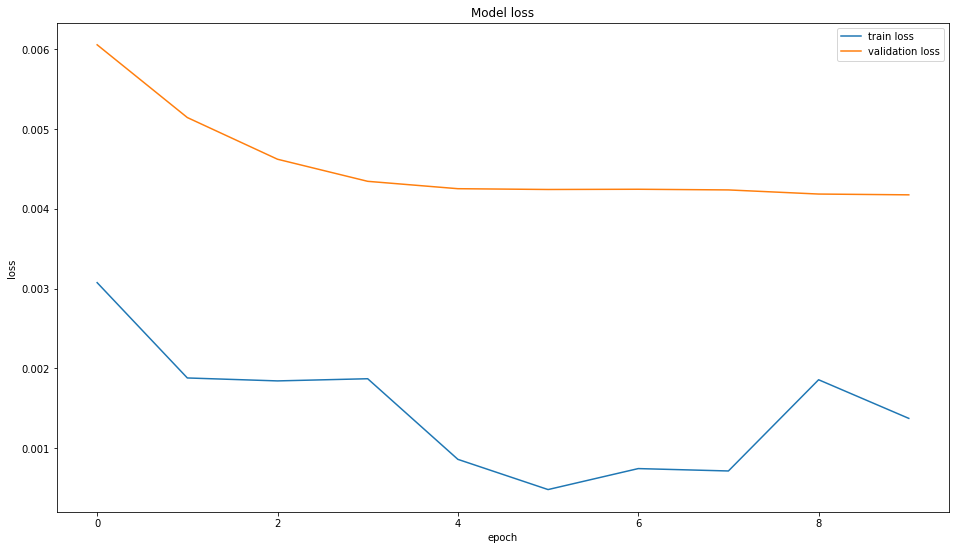

In [54]:
plt.figure(figsize=(16,9))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train loss', 'validation loss'])
plt.show()

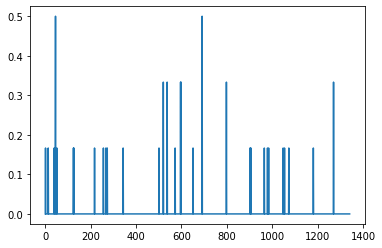

In [92]:
plt.plot(y_test[:,0,0])

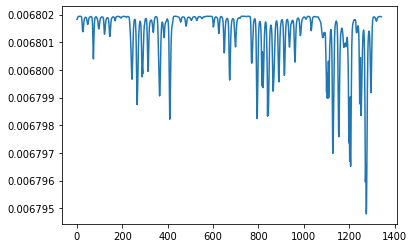

In [86]:
plt.plot(y_pred[:,0,0])
plt

In [71]:
y_pred_Inverse = Y_scaler.inverse_transform(y_pred[0])
y_test_Inverse = Y_scaler.inverse_transform(y_test.reshape(-1,1))

In [72]:
#Average of the RMS of every 10 test and predict values

y_test_rms_list = []
y_rmse_list = []
high_rmse_visual = []
i=200
k=0

for j in range(0,len(y_test_Inverse)):
    y_rmse_list.append(sqrt(mean_squared_error(y_test_Inverse[j],y_pred_Inverse[j])))
    if (y_rmse_list[j] > 1000):
        high_rmse_visual.append(y_pred_Inverse[j])
        

rmse = []
rms = []

for _ in range (len(y_rmse_list)//200):
    rmse.append(sum(y_rmse_list[k:i])/len(y_rmse_list[k:i]))
    rms.append(sqrt(np.mean(np.square(y_test_Inverse[k:i]))))
    k = i
    i += 200
min(rms), min(rmse), max(rms), max(rmse)

ValueError: Found input variables with inconsistent numbers of samples: [1, 10]

In [ ]:

first_predict_value = [ i[0] for i in y_pred_Inverse]
first_test_value = [ i[0] for i in y_test_Inverse]
last_predict_value = [ i[9] for i in y_pred_Inverse]
last_test_value = [ i[9] for i in y_test_Inverse] 

idx = np.array(range(0, len(y_test_Inverse)))

for i in range(100):
    plt.figure(figsize=(10,5))
    plt.plot(idx[i*1000:(i+1)*1000], first_predict_value[i*1000:(i+1)*1000], color = "red", label = 'First Predict')
    plt.plot(idx[i*1000:(i+1)*1000], first_test_value[i*1000:(i+1)*1000], color = "green",label = 'First Actual')
    plt.legend()
    plt.show()
    plt.figure(figsize=(10,5))
    plt.plot(idx[i*1000:(i+1)*1000], last_predict_value[i*1000:(i+1)*1000], color = "red", label = 'Last Predict')
    plt.plot(idx[i*1000:(i+1)*1000], last_test_value[i*1000:(i+1)*1000], color = "blue", label = 'Last Actual')
    plt.legend()
    plt.show()

In [ ]:
First_Predict_RMSE = sqrt(mean_squared_error(first_test_value,first_predict_value))
Last_Predict_RMSE = sqrt(mean_squared_error(last_test_value,last_predict_value))
First_Predict_RMSE, Last_Predict_RMSE

In [ ]:
p = y_pred_Inverse 
t = y_test_Inverse  


RMSE = []
RMS = []

for i,j in zip (p,t):
    RMSE.append(np.sqrt(((j[:10] - i[:10])**2).mean()))

RMSE = np.array(RMSE)

for i in t:
    RMS.append(np.sqrt(((i[:10]) ** 2).mean()))

RMS = np.array(RMS) 

print("RMSE : ",RMSE.mean())
print("RMS : ",RMS.mean())
idx = np.array(range(0, len(RMSE)))

for i in range(100):
    plt.figure(figsize=(13,5))
    print('-'*100)
    plt.plot(idx[i*1000:(i+1)*1000], RMSE[i*1000:(i+1)*1000], color = "red", label = 'RMSE')
    plt.plot(idx[i*1000:(i+1)*1000], RMS[i*1000:(i+1)*1000], color = "blue",label = 'RMS')
    plt.legend()
    plt.show()   

In [ ]:
mse = mean_squared_error(y_test_Inverse ,y_pred_Inverse)
rmse = sqrt(mean_squared_error(y_test_Inverse ,y_pred_Inverse))
rms  = sqrt(np.mean(np.square(y_test_Inverse)))
pred_rms  = sqrt(np.mean(np.square(y_pred_Inverse)))
R2_score = metrics.r2_score(y_test_Inverse ,y_pred_Inverse)
print("Test RMS:", rms)
print("Pred RMS:", pred_rms)
print("MSE:", mse)
print("RMSE:", rmse)
print(f'R2 is :', R2_score)

In [ ]:
y_test_plot = []
y_pred_plot = []
start_point=0
end_point= 200
    
for i in range(0,len(y_test_Inverse)//10):
    y_test_plot.append(y_test_Inverse[i][0])
    y_pred_plot.append(y_pred_Inverse[i][0])
for i in range(0,len(y_test_plot)//end_point):
    plt.figure(figsize=(16,9))
    for j in range(start_point,end_point):
        plt.plot(y_test_plot[start_point:j], color="C0")
        plt.plot(y_pred_plot[start_point:j], color="#fc6825")
    plt.xlim(0,220)
    plt.ylim(-2000, 2100)
    plt.title("Actual vs Predicted")
    plt.ylabel("")
    plt.legend(('Actual','predicted'))
    plt.show()
    start_point = end_point
    end_point += 200